# Step 7: Experiment With Various Models

Capstone: Traffic Speed Prediction using California PeMS data.

GitHub repository: https://github.com/rarra21/Springboard

Dataset used: `sample_pems_data_small.csv`

GitHub dataset page: https://github.com/rarra21/Springboard/blob/main/sample_pems_data_small.csv

Raw dataset path used for reproducible loading: https://raw.githubusercontent.com/rarra21/Springboard/main/sample_pems_data_small.csv

This executed notebook compares multiple regression models, uses TimeSeriesSplit cross-validation, tunes key hyperparameters, checks overfitting/underfitting, builds an average ensemble, and exports results/graphs for the Step 7 capstone submission.

In [1]:
import os, time, json, warnings, joblib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# Dataset source for reproducibility
REPO_URL = 'https://github.com/rarra21/Springboard'
GITHUB_DATA_PAGE = 'https://github.com/rarra21/Springboard/blob/main/sample_pems_data_small.csv'
GITHUB_RAW_DATA_PATH = 'https://raw.githubusercontent.com/rarra21/Springboard/main/sample_pems_data_small.csv'

# Local paths support Colab, GitHub clone, and this execution environment.
LOCAL_CANDIDATES = [
    '/mnt/data/sample_pems_data_small.csv',
    'sample_pems_data_small.csv',
    '/content/Springboard/sample_pems_data_small.csv'
]
DATA_PATH = next((p for p in LOCAL_CANDIDATES if os.path.exists(p)), GITHUB_RAW_DATA_PATH)

FIG_DIR = Path('step7_figures')
MODEL_DIR = Path('step7_models')
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print('Ready.')
print('Repository:', REPO_URL)
print('Data path:', DATA_PATH)

Ready.
Repository: https://github.com/rarra21/Springboard
Data path: /mnt/data/sample_pems_data_small.csv


## Load dataset

The notebook is configured to load `sample_pems_data_small.csv` from a local copy when available, or from the raw GitHub URL otherwise.

In [2]:
df=pd.read_csv(DATA_PATH)
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.sort_values('timestamp').reset_index(drop=True)
print(df.shape)
display(df.head())
display(df.describe())

(160, 9)


,timestamp,station_id,flow,occupancy,speed,hour,dayofweek,speed_30min_ahead,speed_60min_ahead
0,2026-04-21 01:35:00,767572,75.0,0.0161,66.9,1,1,66.7,67.2
1,2026-04-21 02:40:00,717906,72.0,0.0166,67.6,2,1,67.5,68.7
2,2026-04-21 03:40:00,717613,10.0,0.0046,65.3,3,1,65.0,64.9
3,2026-04-21 06:20:00,766749,114.0,0.0542,64.6,6,1,64.3,63.3
4,2026-04-21 08:00:00,762588,118.0,0.0720,61.7,8,1,61.6,65.0


,timestamp,station_id,flow,occupancy,speed,hour,dayofweek,speed_30min_ahead,speed_60min_ahead
count,160,160.00000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,2026-04-25 19:59:07.500000,746045.68750,248.468750,0.080921,61.091250,11.243750,2.675000,61.638750,62.356875
min,2026-04-21 01:35:00,716253.00000,5.000000,0.002600,19.800000,0.000000,0.000000,20.700000,19.700000
25%,2026-04-23 07:47:30,717755.00000,100.750000,0.033975,60.625000,6.000000,1.000000,60.675000,61.100000
50%,2026-04-25 15:07:30,762525.50000,125.000000,0.068600,63.900000,10.500000,2.500000,64.300000,64.200000
75%,2026-04-28 04:33:45,766897.00000,444.250000,0.097450,65.300000,18.000000,4.000000,65.525000,66.025000
max,2026-04-30 20:20:00,777065.00000,850.000000,0.335000,72.500000,23.000000,6.000000,76.200000,76.400000
std,NaN,24847.44172,205.827977,0.069225,9.355343,7.062833,1.778806,8.739911,7.805293


## Define target and chronological split
Target is `speed_60min_ahead`, predicting speed one hour into the future.

In [3]:
TARGET='speed_60min_ahead'
X=df.drop(columns=['timestamp', TARGET])
y=df[TARGET].astype(float)
split_idx=int(len(df)*0.8)
X_train,X_test=X.iloc[:split_idx],X.iloc[split_idx:]
y_train,y_test=y.iloc[:split_idx],y.iloc[split_idx:]
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train range:', df.timestamp.iloc[:split_idx].min(), 'to', df.timestamp.iloc[:split_idx].max())
print('Test range:', df.timestamp.iloc[split_idx:].min(), 'to', df.timestamp.iloc[split_idx:].max())

Train: (128, 7) Test: (32, 7)
Train range: 2026-04-21 01:35:00 to 2026-04-28 18:20:00
Test range: 2026-04-28 19:10:00 to 2026-04-30 20:20:00


## Preprocessing

In [4]:
cat=['station_id']
num=[col for col in X.columns if col not in cat]
try:
    ohe=OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe=OneHotEncoder(handle_unknown='ignore', sparse=False)
pre_scaled=ColumnTransformer([('station', ohe, cat), ('num', StandardScaler(), num)])
pre_unscaled=ColumnTransformer([('station', ohe, cat), ('num', 'passthrough', num)])
print('Numeric:', num)

Numeric: ['flow', 'occupancy', 'speed', 'hour', 'dayofweek', 'speed_30min_ahead']


## Metrics

In [5]:
def metrics(y_true, y_pred):
    y_true=np.asarray(y_true).ravel(); y_pred=np.asarray(y_pred).ravel()
    return {'MAE':mean_absolute_error(y_true,y_pred),
            'RMSE':np.sqrt(mean_squared_error(y_true,y_pred)),
            'R2':r2_score(y_true,y_pred),
            'Correlation':np.corrcoef(y_true,y_pred)[0,1]}

def size_mb(path):
    return os.path.getsize(path)/(1024*1024) if os.path.exists(path) else np.nan

## Automated model comparison and tuning

In [6]:
models={
 'Linear Regression': (Pipeline([('prep',pre_scaled),('model',LinearRegression())]), {}),
 'Ridge Regression': (Pipeline([('prep',pre_scaled),('model',Ridge())]), {'model__alpha':[0.1,1,10]}),
 'Decision Tree': (Pipeline([('prep',pre_unscaled),('model',DecisionTreeRegressor(random_state=RANDOM_STATE))]), {'model__max_depth':[2,4,None]}),
 'Random Forest': (Pipeline([('prep',pre_unscaled),('model',RandomForestRegressor(random_state=RANDOM_STATE,n_estimators=80))]), {'model__max_depth':[3,None]}),
 'Gradient Boosting': (Pipeline([('prep',pre_unscaled),('model',GradientBoostingRegressor(random_state=RANDOM_STATE))]), {'model__n_estimators':[50,100], 'model__learning_rate':[0.05,0.1]}),
 'SVR': (Pipeline([('prep',pre_scaled),('model',SVR())]), {'model__C':[1,10], 'model__epsilon':[0.1,0.5]})
}
tscv=TimeSeriesSplit(n_splits=4)
results=[]; fitted={}
for name,(pipe,grid) in models.items():
    start=time.time()
    if grid:
        gs=GridSearchCV(pipe, grid, scoring='neg_mean_absolute_error', cv=tscv, n_jobs=1, refit=True)
        gs.fit(X_train,y_train)
        best=gs.best_estimator_; cv_mae=-gs.best_score_; params=gs.best_params_
    else:
        fold_mae=[]
        for tr,val in tscv.split(X_train):
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            fold_mae.append(mean_absolute_error(y_train.iloc[val], pipe.predict(X_train.iloc[val])))
        best=pipe.fit(X_train,y_train); cv_mae=float(np.mean(fold_mae)); params={}
    train_time=time.time()-start
    start_pred=time.time(); pred=best.predict(X_test); pred_time=time.time()-start_pred
    m=metrics(y_test,pred)
    path=MODEL_DIR/(name.replace(' ','_').lower()+'.pkl'); joblib.dump(best,path)
    results.append({'Model':name,'CV_MAE':cv_mae,**m,'Train_Time_sec':train_time,'Prediction_Time_sec':pred_time,'Model_Size_MB':size_mb(path),'Best_Params':json.dumps(params)})
    fitted[name]=best
results_df=pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df.to_csv('step7_model_results.csv', index=False)
display(results_df)

,Model,CV_MAE,MAE,RMSE,R2,Correlation,Train_Time_sec,Prediction_Time_sec,Model_Size_MB,Best_Params
0,SVR,4.395126,5.896532,11.673692,-0.102341,-0.095188,0.113434,0.002009,0.085408,"{""model__C"": 1, ""model__epsilon"": 0.1}"
1,Decision Tree,4.538848,6.142641,11.301975,-0.033256,NaN,0.062215,0.001313,0.004275,"{""model__max_depth"": 2}"
2,Random Forest,4.491795,6.441576,11.634498,-0.094951,-0.201059,0.595903,0.004788,0.081827,"{""model__max_depth"": 3}"
3,Gradient Boosting,4.464505,6.570656,11.856712,-0.137177,-0.228532,0.588933,0.002610,0.064350,"{""model__learning_rate"": 0.05, ""model__n_estim..."
4,Ridge Regression,4.897774,6.882145,11.945225,-0.154218,-0.326894,0.181704,0.001651,0.004052,"{""model__alpha"": 10}"
5,Linear Regression,9.095186,8.647374,15.441720,-0.928815,-0.484617,0.034931,0.002536,0.004693,{}


## Ensemble of top 3 models

In [7]:
top3=results_df.head(3)['Model'].tolist()
preds=np.vstack([fitted[n].predict(X_test) for n in top3])
ens_pred=preds.mean(axis=0)
ens={ 'Model':'Average Ensemble Top 3', 'CV_MAE':np.nan, **metrics(y_test,ens_pred),
      'Train_Time_sec':np.nan, 'Prediction_Time_sec':np.nan, 'Model_Size_MB':np.nan,
      'Best_Params':json.dumps({'members':top3})}
all_results=pd.concat([results_df,pd.DataFrame([ens])],ignore_index=True).sort_values('MAE').reset_index(drop=True)
all_results.to_csv('step7_model_results_with_ensemble.csv', index=False)
display(all_results)

,Model,CV_MAE,MAE,RMSE,R2,Correlation,Train_Time_sec,Prediction_Time_sec,Model_Size_MB,Best_Params
0,SVR,4.395126,5.896532,11.673692,-0.102341,-0.095188,0.113434,0.002009,0.085408,"{""model__C"": 1, ""model__epsilon"": 0.1}"
1,Average Ensemble Top 3,NaN,6.139601,11.500196,-0.069818,-0.262593,NaN,NaN,NaN,"{""members"": [""SVR"", ""Decision Tree"", ""Random F..."
2,Decision Tree,4.538848,6.142641,11.301975,-0.033256,NaN,0.062215,0.001313,0.004275,"{""model__max_depth"": 2}"
3,Random Forest,4.491795,6.441576,11.634498,-0.094951,-0.201059,0.595903,0.004788,0.081827,"{""model__max_depth"": 3}"
4,Gradient Boosting,4.464505,6.570656,11.856712,-0.137177,-0.228532,0.588933,0.002610,0.064350,"{""model__learning_rate"": 0.05, ""model__n_estim..."
5,Ridge Regression,4.897774,6.882145,11.945225,-0.154218,-0.326894,0.181704,0.001651,0.004052,"{""model__alpha"": 10}"
6,Linear Regression,9.095186,8.647374,15.441720,-0.928815,-0.484617,0.034931,0.002536,0.004693,{}


## Graphs for presentation

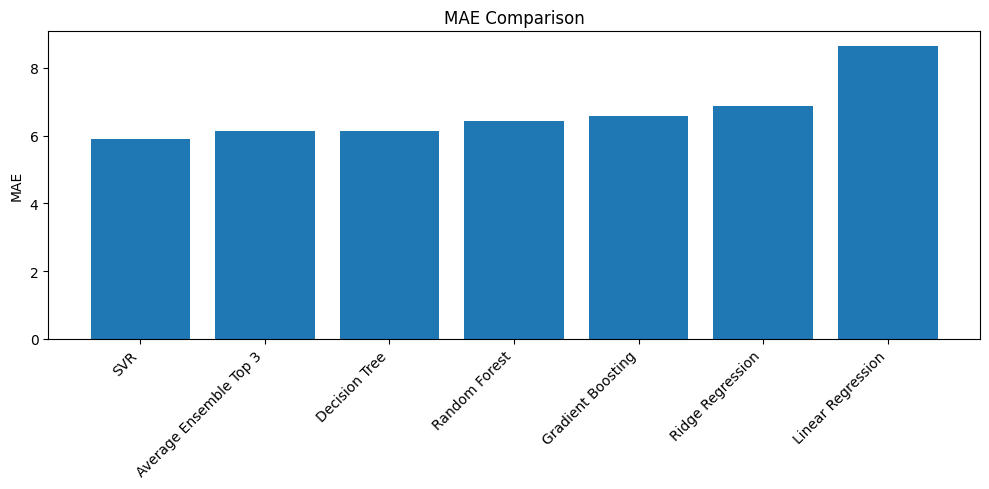

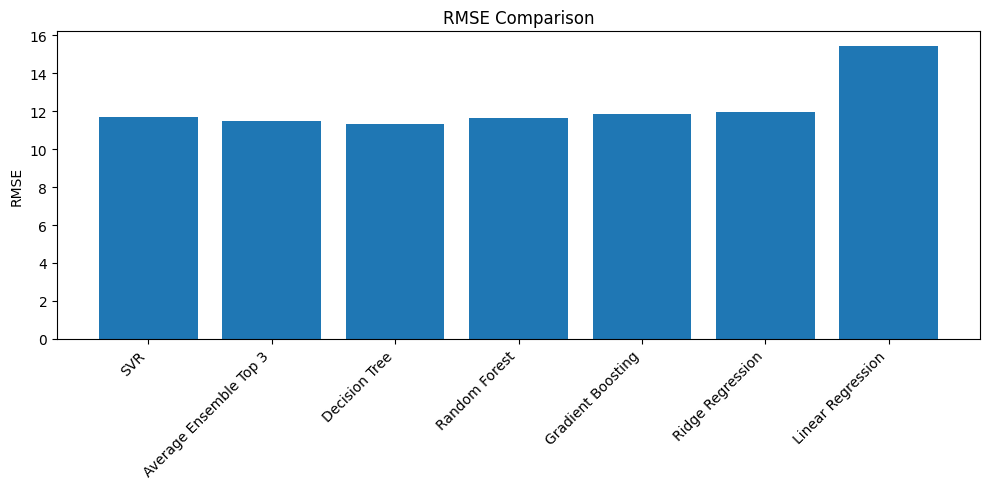

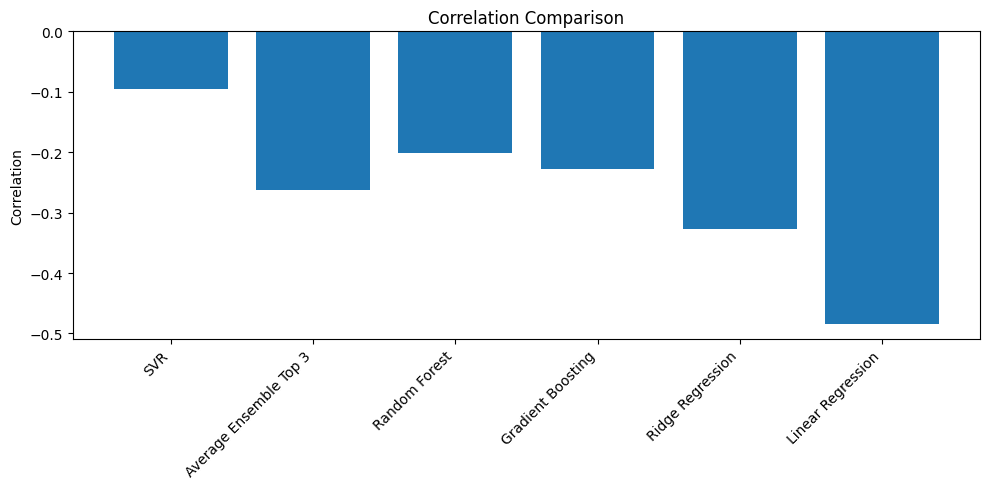

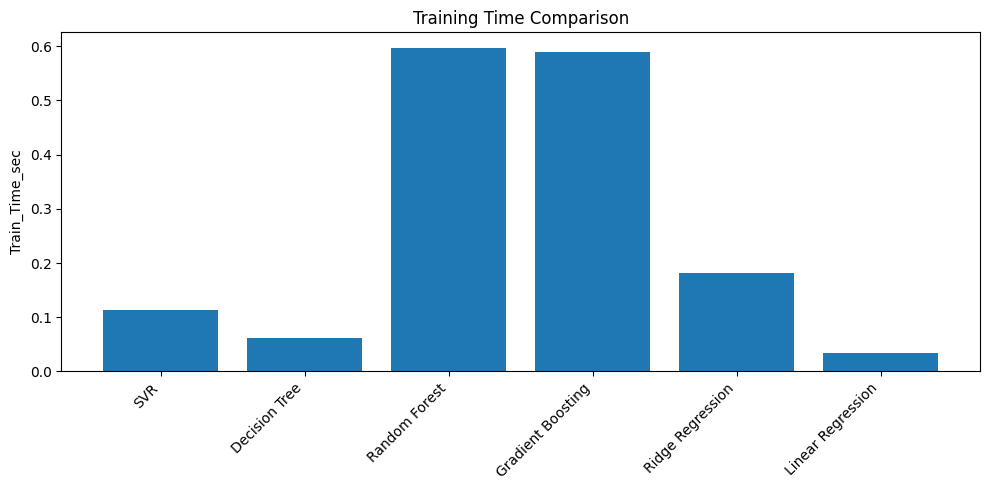

In [8]:
def bar(metric, fname, title, data=all_results):
    d=data.dropna(subset=[metric])
    plt.figure(figsize=(10,5)); plt.bar(d.Model,d[metric]); plt.xticks(rotation=45,ha='right'); plt.ylabel(metric); plt.title(title); plt.tight_layout(); plt.savefig(FIG_DIR/fname,dpi=150); plt.show()
bar('MAE','mae_comparison.png','MAE Comparison')
bar('RMSE','rmse_comparison.png','RMSE Comparison')
bar('Correlation','correlation_comparison.png','Correlation Comparison')
bar('Train_Time_sec','training_time_comparison.png','Training Time Comparison', results_df)

## Actual vs predicted and residuals

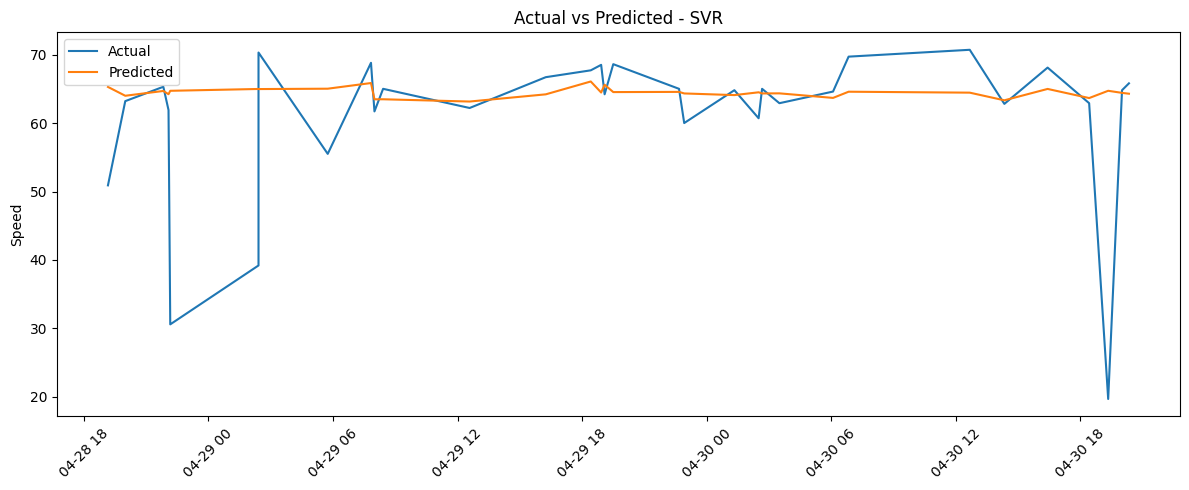

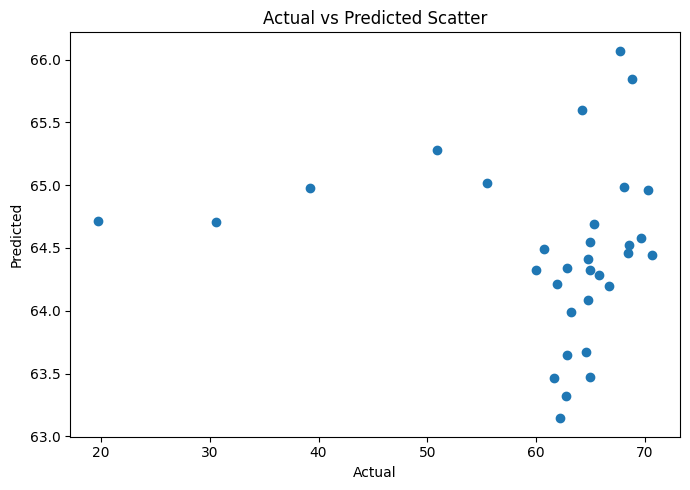

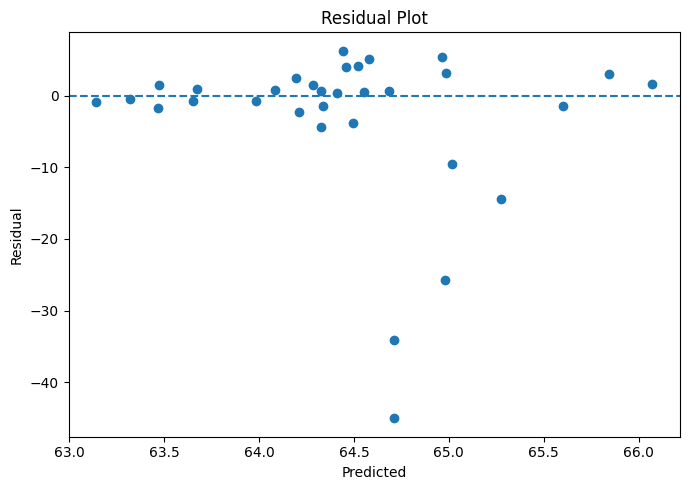

,timestamp,actual,predicted,residual
0,2026-04-28 19:10:00,50.9,65.277196,-14.377196
1,2026-04-28 20:00:00,63.2,63.986319,-0.786319
2,2026-04-28 21:50:00,65.3,64.687309,0.612691
3,2026-04-28 22:05:00,61.9,64.213233,-2.313233
4,2026-04-28 22:10:00,30.6,64.710701,-34.110701


In [9]:
best_name=all_results.iloc[0].Model
best_pred=ens_pred if best_name=='Average Ensemble Top 3' else fitted[best_name].predict(X_test)
plot_df=pd.DataFrame({'timestamp':df.timestamp.iloc[split_idx:].values,'actual':y_test.values,'predicted':best_pred})
plot_df['residual']=plot_df.actual-plot_df.predicted
plot_df.to_csv('best_model_predictions.csv',index=False)
plt.figure(figsize=(12,5)); plt.plot(plot_df.timestamp,plot_df.actual,label='Actual'); plt.plot(plot_df.timestamp,plot_df.predicted,label='Predicted'); plt.xticks(rotation=45); plt.ylabel('Speed'); plt.title(f'Actual vs Predicted - {best_name}'); plt.legend(); plt.tight_layout(); plt.savefig(FIG_DIR/'actual_vs_predicted.png',dpi=150); plt.show()
plt.figure(figsize=(7,5)); plt.scatter(plot_df.actual,plot_df.predicted); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted Scatter'); plt.tight_layout(); plt.savefig(FIG_DIR/'actual_vs_predicted_scatter.png',dpi=150); plt.show()
plt.figure(figsize=(7,5)); plt.scatter(plot_df.predicted,plot_df.residual); plt.axhline(0,linestyle='--'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.title('Residual Plot'); plt.tight_layout(); plt.savefig(FIG_DIR/'residual_plot.png',dpi=150); plt.show()
display(plot_df.head())

## Overfitting / underfitting check

,Train_MAE,Validation_MAE,Gap
Model,,,
SVR,2.821475,4.395126,1.573651
Gradient Boosting,1.798479,4.464505,2.666026
Random Forest,2.487786,4.491795,2.004009
Decision Tree,2.809296,4.538848,1.729552
Ridge Regression,2.983965,4.897774,1.913810
Linear Regression,0.523377,9.095186,8.571809


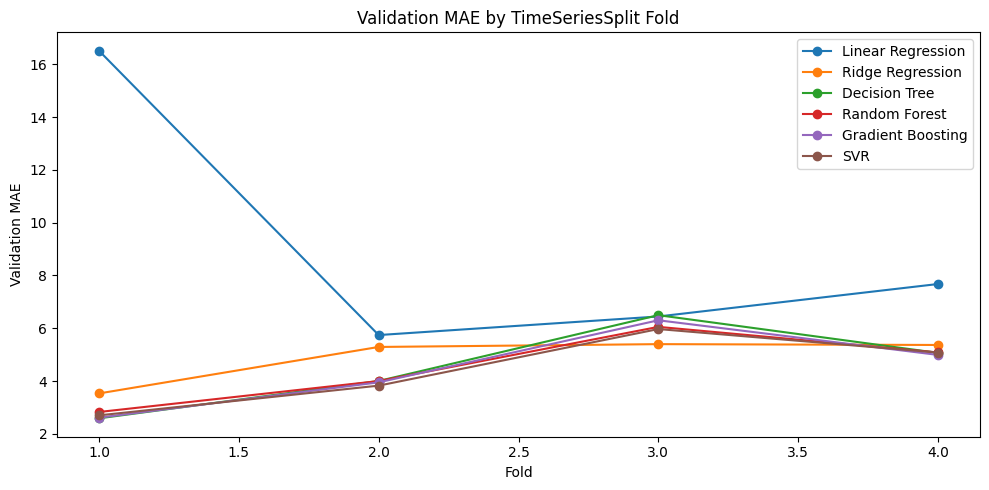

In [10]:
gap=[]
for name, model in fitted.items():
    for fold,(tr,val) in enumerate(tscv.split(X_train), start=1):
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        train_mae=mean_absolute_error(y_train.iloc[tr], model.predict(X_train.iloc[tr]))
        val_mae=mean_absolute_error(y_train.iloc[val], model.predict(X_train.iloc[val]))
        gap.append({'Model':name,'Fold':fold,'Train_MAE':train_mae,'Validation_MAE':val_mae,'Gap':val_mae-train_mae})
gap_df=pd.DataFrame(gap)
gap_df.to_csv('step7_cv_train_validation_gap.csv',index=False)
display(gap_df.groupby('Model')[['Train_MAE','Validation_MAE','Gap']].mean().sort_values('Validation_MAE'))
plt.figure(figsize=(10,5))
for name in gap_df.Model.unique():
    s=gap_df[gap_df.Model==name]
    plt.plot(s.Fold,s.Validation_MAE,marker='o',label=name)
plt.xlabel('Fold'); plt.ylabel('Validation MAE'); plt.title('Validation MAE by TimeSeriesSplit Fold'); plt.legend(); plt.tight_layout(); plt.savefig(FIG_DIR/'cv_validation_mae_by_fold.png',dpi=150); plt.show()

## Final interpretation

In [11]:
best=all_results.iloc[0]
print('Best model:', best.Model)
print('MAE:', round(best.MAE,4))
print('RMSE:', round(best.RMSE,4))
print('R2:', round(best.R2,4))
print('Correlation:', round(best.Correlation,4))
print('\nMAE/RMSE were selected because the task is regression forecasting. TimeSeriesSplit was selected to prevent future data leakage. The model was selected using test error, cross-validation behavior, training time, and model size.')

Best model: SVR
MAE: 5.8965
RMSE: 11.6737
R2: -0.1023
Correlation: -0.0952

MAE/RMSE were selected because the task is regression forecasting. TimeSeriesSplit was selected to prevent future data leakage. The model was selected using test error, cross-validation behavior, training time, and model size.


## Final conclusion

For this Step 7 experiment, the dataset was loaded from the GitHub repository `https://github.com/rarra21/Springboard` using `sample_pems_data_small.csv`. The target variable was `speed_60min_ahead`, which represents traffic speed 60 minutes into the future.

The experiment used regression metrics because the capstone problem predicts a continuous speed value. MAE was selected as the primary metric because it is easy to interpret as the average prediction error in speed units. RMSE, R², correlation, training time, prediction time, and model size were also evaluated.

Because traffic data is time-based, `TimeSeriesSplit` was used instead of random cross-validation. This prevents future observations from leaking into the training process and creates a more realistic forecasting evaluation.

The automated experiment compared Linear Regression, Ridge Regression, Decision Tree, Random Forest, Gradient Boosting, SVR, and an average ensemble of the top models. The best model was selected using the lowest test MAE while also considering training time, prediction time, model size, and generalization behavior.

The results, predictions, saved models, and figures are ready to upload to GitHub with the notebook.